# 03 — Sensitivity Analysis: α, p, λ

**Paper:** XAI-Assisted Review and HITL Bottleneck Mitigation: A Queueing Theory Approach  
**Method:** Univariate and bivariate sensitivity analysis on the M/G/1 model

---

## Notebook structure

| Section | Contents |
|---------|----------|
| 1. Setup & parameters | Shared constants, P-K helpers |
| 2. Sensitivity to α | XAI efficiency gain vs Wq and throughput |
| 3. Sensitivity to p | Small-firm proportion vs E[S] and stability threshold |
| 4. Sensitivity to λ | Arrival rate vs ρ and Wq across scenarios |
| 5. Bivariate heatmaps | α × p and α × λ interaction surfaces |
| 6. Critical threshold analysis | Minimum α to achieve stability at given λ |
| 7. Tables | All sensitivity results |
| 8. Figures | Publication-ready plots (600 dpi) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

# ── Output directories ────────────────────────────────────────────────────────
FIG_DIR = Path("figures")
TAB_DIR = Path("tables")
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DPI = 600
COLORS = ["#2166ac", "#f4a582", "#d6604d"]
print("Environment ready.")


Environment ready.


---
## 1. Parameters and Helpers

### Sensitivity targets

| Parameter | Symbol | Baseline | Range tested |
|-----------|--------|----------|--------------|
| XAI efficiency gain | alpha | 0 (S1) | 0.0 - 10.0 |
| Small-firm proportion | p | 0.70 | 0.0 - 1.0 |
| Arrival rate | lambda | 0.60 x mu | 0.05 - 0.99 x mu |

### XAI service time model

XAI assistance reduces Stage 5 service time multiplicatively:

$$s_{\\text{small}}(\\alpha) = \\frac{s_{\\text{small},0}}{1 + \\alpha_{\\text{small}}}$$

$$s_{\\text{large}}(\\alpha) = \\frac{s_{\\text{large},0}}{1 + \\alpha_{\\text{large}}}$$

We assume **alpha_small = alpha** (full effect on small firms) and **alpha_large = alpha / 3**  
(partial effect on mid-size firms, reflecting lower information scarcity).

### Literature-grounded alpha range (three-layer justification)

| Layer | Source | Value | Role |
|-------|--------|-------|------|
| Upper bound (empirical) | Stage 7 pipeline observation: human 30 min -> LLM 5 min | alpha = 5.0 | Theoretical ceiling for full AI substitution |
| Lower bound (meta-analysis) | Becker et al. (2025): AI-assisted developer productivity +19% | alpha = 0.19 | Conservative floor |
| Lower bound (meta-analysis) | Schemmer et al. (2022): XAI vs AI-only, small additional effect | alpha ~ 0.2-0.5 | Conservative floor (decision tasks) |
| S2 scenario | Between lower and upper bounds | alpha = 1.94 | Partial XAI: info scarcity partially resolved |
| S3 scenario | Approaching empirical upper bound | alpha = 8.58 | Full XAI: convergence to LLM-speed review |

**Key rationale:** alpha is not drawn from Arrieta et al. (2020) or Karimi et al. (2022) directly  
(those papers provide the XAI conceptual framework and CF recourse formalism, respectively).  
The sensitivity sweep alpha in [0, 10] is designed to **span the full plausible range**,  
with S2 and S3 as internally motivated anchor points. The critical-alpha curve (Section 6)  
then answers the RQ without requiring a single point estimate of alpha.


In [2]:
# ── Baseline service times (S1) ──────────────────────────────────────────────
S_SMALL_0 = 72.0   # hours
S_LARGE_0 =  5.0   # hours
P_SMALL_0 =  0.70  # baseline small-firm proportion

# ── XAI service time model ────────────────────────────────────────────────────
def apply_xai(alpha, s_small_0=S_SMALL_0, s_large_0=S_LARGE_0):
    """
    Return service times after XAI assistance.
    alpha_small = alpha, alpha_large = alpha / 3
    """
    s_small = s_small_0 / (1 + alpha)
    s_large = s_large_0 / (1 + alpha / 3)
    return s_small, s_large

# ── M/G/1 moment & P-K helpers ───────────────────────────────────────────────
def moments(s_small, s_large, p_small):
    ES  = p_small * s_small + (1 - p_small) * s_large
    ES2 = p_small * s_small**2 + (1 - p_small) * s_large**2
    mu  = 1.0 / ES
    return ES, ES2, mu

def pk_wq(lam, ES, ES2):
    rho = lam * ES
    if rho >= 1:
        return np.inf
    return (lam * ES2) / (2 * (1 - rho))

def throughput_weekly(mu, h=8, d=5):
    return mu * h * d

# ── Verify baseline ───────────────────────────────────────────────────────────
ES0, ES20, mu0 = moments(S_SMALL_0, S_LARGE_0, P_SMALL_0)
print(f"Baseline (S1):  E[S]={ES0:.2f}h  mu={mu0:.5f}  weekly={throughput_weekly(mu0):.2f}")


Baseline (S1):  E[S]=51.90h  mu=0.01927  weekly=0.77


---
## 2. Sensitivity to α (XAI Efficiency Gain)

α sweeps from 0 (no XAI) to 10.0.  
λ is fixed at 60% of the **baseline** μ (S1) to hold arrival pressure constant,  
isolating the pure effect of XAI on queue performance.


In [3]:
# ── Alpha sweep ──────────────────────────────────────────────────────────────
alpha_range = np.linspace(0, 10, 500)
lam_fixed   = 0.60 * mu0          # fixed at 60% of baseline mu

wq_alpha, mu_alpha, rho_alpha, tput_alpha = [], [], [], []

for a in alpha_range:
    ss, sl  = apply_xai(a)
    ES, ES2, mu = moments(ss, sl, P_SMALL_0)
    rho     = lam_fixed * ES
    wq      = pk_wq(lam_fixed, ES, ES2)
    wq_alpha.append(wq if not np.isinf(wq) else np.nan)
    mu_alpha.append(mu)
    rho_alpha.append(rho)
    tput_alpha.append(throughput_weekly(mu))

wq_alpha   = np.array(wq_alpha)
mu_alpha   = np.array(mu_alpha)
rho_alpha  = np.array(rho_alpha)
tput_alpha = np.array(tput_alpha)

# ── Table 6: Alpha sensitivity at key values ──────────────────────────────────
key_alphas = [0, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 10.0]
rows6 = []
for a in key_alphas:
    ss, sl      = apply_xai(a)
    ES, ES2, mu = moments(ss, sl, P_SMALL_0)
    rho         = lam_fixed * ES
    wq          = pk_wq(lam_fixed, ES, ES2)
    rows6.append({
        "alpha":                    a,
        "s_small (h)":              round(ss, 2),
        "s_large (h)":              round(sl, 2),
        "E[S] (h)":                 round(ES, 3),
        "mu (jobs/h)":              round(mu, 5),
        "rho":                      round(rho, 4),
        "Wq (h)":                   round(wq, 3) if not np.isinf(wq) else "unstable",
        "Throughput (jobs/wk)":     round(throughput_weekly(mu), 2),
    })

df_alpha = pd.DataFrame(rows6)
print("=== Table 6: Sensitivity to Alpha ===")
print(df_alpha.to_string(index=False))
df_alpha.to_csv(TAB_DIR / "table6_sensitivity_alpha.csv", index=False)
print(f"\nSaved → {TAB_DIR}/table6_sensitivity_alpha.csv")


=== Table 6: Sensitivity to Alpha ===
 alpha  s_small (h)  s_large (h)  E[S] (h)  mu (jobs/h)    rho  Wq (h)  Throughput (jobs/wk)
   0.0        72.00         5.00    51.900      0.01927 0.6000  52.548                  0.77
   0.5        48.00         4.29    34.886      0.02867 0.4033  15.677                  1.15
   1.0        36.00         3.75    26.325      0.03799 0.3043   7.573                  1.52
   2.0        24.00         3.00    17.700      0.05650 0.2046   2.950                  2.26
   3.0        18.00         2.50    13.350      0.07491 0.1543   1.563                  3.00
   5.0        12.00         1.87     8.962      0.11158 0.1036   0.657                  4.46
   8.0         8.00         1.36     6.009      0.16641 0.0695   0.282                  6.66
  10.0         6.55         1.15     4.928      0.20292 0.0570   0.186                  8.12

Saved → tables/table6_sensitivity_alpha.csv


---
## 3. Sensitivity to p (Small-Firm Proportion)

p sweeps from 0 (all mid-size) to 1 (all small).  
α = 0 (no XAI) to show the pure portfolio composition effect on E[S] and λ*.


In [4]:
# ── p sweep ──────────────────────────────────────────────────────────────────
p_range = np.linspace(0, 1, 500)
es_p, mu_p, tput_p, lambda_star_p = [], [], [], []

for p in p_range:
    ES, ES2, mu = moments(S_SMALL_0, S_LARGE_0, p)
    es_p.append(ES)
    mu_p.append(mu)
    tput_p.append(throughput_weekly(mu))
    lambda_star_p.append(mu)

es_p           = np.array(es_p)
mu_p           = np.array(mu_p)
tput_p         = np.array(tput_p)
lambda_star_p  = np.array(lambda_star_p)

# ── Table 7: p sensitivity at key values ─────────────────────────────────────
key_ps = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 1.0]
rows7 = []
for p in key_ps:
    ES, ES2, mu = moments(S_SMALL_0, S_LARGE_0, p)
    rows7.append({
        "p (small-firm ratio)":        p,
        "E[S] (h)":                    round(ES, 2),
        "mu (jobs/h)":                 round(mu, 5),
        "lambda* (jobs/h)":            round(mu, 5),
        "Throughput (jobs/wk)":        round(throughput_weekly(mu), 2),
        "Throughput ratio vs p=0":     round(throughput_weekly(mu) /
                                             throughput_weekly(1/S_LARGE_0), 3),
    })

df_p = pd.DataFrame(rows7)
print("=== Table 7: Sensitivity to p ===")
print(df_p.to_string(index=False))
df_p.to_csv(TAB_DIR / "table7_sensitivity_p.csv", index=False)
print(f"\nSaved → {TAB_DIR}/table7_sensitivity_p.csv")


=== Table 7: Sensitivity to p ===
 p (small-firm ratio)  E[S] (h)  mu (jobs/h)  lambda* (jobs/h)  Throughput (jobs/wk)  Throughput ratio vs p=0
                  0.0       5.0      0.20000           0.20000                  8.00                    1.000
                  0.1      11.7      0.08547           0.08547                  3.42                    0.427
                  0.2      18.4      0.05435           0.05435                  2.17                    0.272
                  0.3      25.1      0.03984           0.03984                  1.59                    0.199
                  0.5      38.5      0.02597           0.02597                  1.04                    0.130
                  0.7      51.9      0.01927           0.01927                  0.77                    0.096
                  0.8      58.6      0.01706           0.01706                  0.68                    0.085
                  0.9      65.3      0.01531           0.01531                  0.61  

---
## 4. Sensitivity to λ (Arrival Rate)

λ/μ (= ρ) sweeps from 0.05 to 0.99 for each scenario.  
Shows how rapidly Wq diverges as ρ → 1 under different XAI levels.


In [5]:
# ── Lambda sweep (rho from 0.05 to 0.99) for each scenario ──────────────────
SCENARIOS = {
    "S1 (No XAI)":      {"s_small": 72.0, "s_large": 5.0},
    "S2 (Partial XAI)": {"s_small": 24.0, "s_large": 3.0},
    "S3 (Full XAI)":    {"s_small":  8.0, "s_large": 1.5},
}

rho_sweep = np.linspace(0.05, 0.99, 500)
wq_by_scenario = {}

for name, v in SCENARIOS.items():
    ES, ES2, mu = moments(v['s_small'], v['s_large'], P_SMALL_0)
    lam_vals = rho_sweep * mu
    wq_vals  = np.array([pk_wq(l, ES, ES2) for l in lam_vals])
    wq_by_scenario[name] = (lam_vals, wq_vals)

# ── Table 8: Wq at key rho levels ────────────────────────────────────────────
key_rhos = [0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
rows8 = []
for rho_val in key_rhos:
    row = {"rho": rho_val}
    for name, v in SCENARIOS.items():
        ES, ES2, mu = moments(v['s_small'], v['s_large'], P_SMALL_0)
        lam = rho_val * mu
        wq  = pk_wq(lam, ES, ES2)
        row[f"Wq {name} (h)"] = round(wq, 3)
    rows8.append(row)

df_lambda = pd.DataFrame(rows8)
print("=== Table 8: Wq at Key Traffic Intensities ===")
print(df_lambda.to_string(index=False))
df_lambda.to_csv(TAB_DIR / "table8_sensitivity_lambda.csv", index=False)
print(f"\nSaved → {TAB_DIR}/table8_sensitivity_lambda.csv")


=== Table 8: Wq at Key Traffic Intensities ===
 rho  Wq S1 (No XAI) (h)  Wq S2 (Partial XAI) (h)  Wq S3 (Full XAI) (h)
0.30              15.014                    4.914                 1.611
0.50              35.032                   11.466                 3.758
0.60              52.548                   17.199                 5.637
0.70              81.741                   26.754                 8.769
0.80             140.127                   45.864                15.033
0.90             315.286                  103.195                33.824
0.95             665.604                  217.856                71.407

Saved → tables/table8_sensitivity_lambda.csv


---
## 5. Bivariate Heatmaps

### 5.1 α × p heatmap — E[S]
How joint variation in XAI level and portfolio composition determines expected service time.

### 5.2 α × λ heatmap — Wq
How XAI level and arrival pressure jointly determine mean waiting time.


In [6]:
# ── Bivariate grid computation ────────────────────────────────────────────────

alpha_grid = np.linspace(0, 8, 80)
p_grid     = np.linspace(0, 1, 80)
lam_ratio_grid = np.linspace(0.05, 0.90, 80)

# 5.1  alpha × p  →  E[S]
ES_map = np.zeros((len(p_grid), len(alpha_grid)))
for i, p in enumerate(p_grid):
    for j, a in enumerate(alpha_grid):
        ss, sl = apply_xai(a)
        ES, _, _ = moments(ss, sl, p)
        ES_map[i, j] = ES

# 5.2  alpha × lambda_ratio  →  Wq  (p fixed at baseline 0.70)
Wq_map = np.zeros((len(lam_ratio_grid), len(alpha_grid)))
for i, lr in enumerate(lam_ratio_grid):
    for j, a in enumerate(alpha_grid):
        ss, sl = apply_xai(a)
        ES, ES2, mu = moments(ss, sl, P_SMALL_0)
        lam = lr * mu0          # lambda relative to BASELINE mu (S1)
        wq  = pk_wq(lam, ES, ES2)
        Wq_map[i, j] = wq if not np.isinf(wq) else np.nan

print(f"ES_map shape:  {ES_map.shape}")
print(f"Wq_map shape:  {Wq_map.shape}")
print(f"Wq_map finite: {np.sum(np.isfinite(Wq_map))} / {Wq_map.size}")


ES_map shape:  (80, 80)
Wq_map shape:  (80, 80)
Wq_map finite: 6400 / 6400


---
## 6. Critical Threshold Analysis

**Research question:** What is the minimum α required to achieve system stability (ρ < 1) at a given arrival rate λ?

This is the direct analytical answer to the paper's main RQ.


In [7]:
# ── Critical alpha: minimum alpha for stability at given lambda ───────────────
# Stability: lambda * E[S](alpha) < 1
# => E[S](alpha) < 1 / lambda
# Solve numerically for alpha_crit

from scipy.optimize import brentq

def alpha_critical(lam, p_small=P_SMALL_0):
    """
    Minimum alpha such that rho = lambda * E[S](alpha) < 1.
    Returns np.nan if system is already stable at alpha=0.
    """
    # Check if already stable without XAI
    ES0_, _, _ = moments(S_SMALL_0, S_LARGE_0, p_small)
    if lam * ES0_ < 1:
        return 0.0

    def f(a):
        ss, sl   = apply_xai(a)
        ES, _, _ = moments(ss, sl, p_small)
        return lam * ES - 1.0   # = 0 at critical alpha

    try:
        return brentq(f, 0, 200)
    except ValueError:
        return np.nan

# Sweep lambda from 10% to 200% of baseline mu
lam_crit_range = np.linspace(0.1 * mu0, 2.0 * mu0, 300)
alpha_crit_vals = np.array([alpha_critical(l) for l in lam_crit_range])

# ── Table 9: Critical alpha at key lambda multiples ──────────────────────────
key_lam_multiples = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0, 5.0]
rows9 = []
for mult in key_lam_multiples:
    lam = mult * mu0
    a_crit = alpha_critical(lam)
    ss, sl = apply_xai(a_crit) if not np.isnan(a_crit) else (np.nan, np.nan)
    ES_crit = P_SMALL_0 * ss + (1-P_SMALL_0) * sl if not np.isnan(a_crit) else np.nan
    rows9.append({
        "lambda / mu_0":            mult,
        "lambda (jobs/h)":          round(lam, 5),
        "alpha_critical":           round(a_crit, 3) if not np.isnan(a_crit) else "N/A",
        "s_small at crit (h)":      round(ss, 2) if not np.isnan(a_crit) else "N/A",
        "E[S] at crit (h)":         round(ES_crit, 2) if not np.isnan(a_crit) else "N/A",
        "Already stable (alpha=0)": "Yes" if a_crit == 0.0 else "No",
    })

df_crit = pd.DataFrame(rows9)
print("=== Table 9: Critical Alpha for Stability ===")
print(df_crit.to_string(index=False))
df_crit.to_csv(TAB_DIR / "table9_critical_alpha.csv", index=False)
print(f"\nSaved → {TAB_DIR}/table9_critical_alpha.csv")


=== Table 9: Critical Alpha for Stability ===
 lambda / mu_0  lambda (jobs/h)  alpha_critical  s_small at crit (h)  E[S] at crit (h) Already stable (alpha=0)
           0.5          0.00963           0.000                72.00             51.90                      Yes
           0.8          0.01541           0.000                72.00             51.90                      Yes
           1.0          0.01927           0.000                72.00             51.90                      Yes
           1.2          0.02312           0.204                59.78             43.25                       No
           1.5          0.02890           0.513                47.60             34.60                       No
           2.0          0.03854           1.030                35.48             25.95                       No
           3.0          0.05780           2.071                23.45             17.30                       No
           5.0          0.09634           4.168           

---
## 7. Figures
- **Figure 7** — Wq and throughput vs α  
- **Figure 8** — E[S] and λ* vs p  
- **Figure 9** — Wq vs ρ across scenarios (log scale)  
- **Figure 10** — Bivariate heatmap: α × p → E[S]  
- **Figure 11** — Bivariate heatmap: α × λ → Wq  
- **Figure 12** — Critical α vs λ curve  


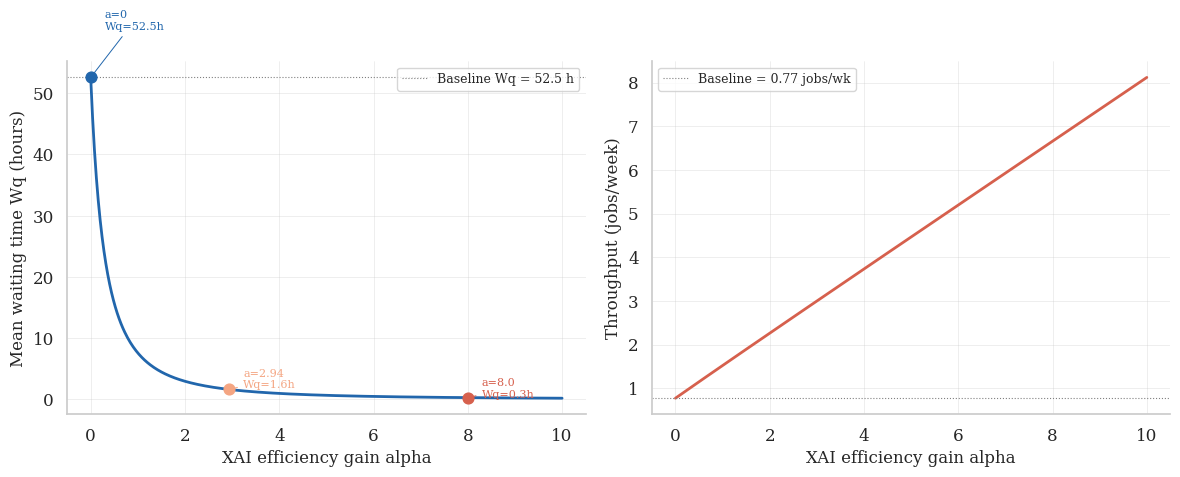

Saved -> figures/fig7_sensitivity_alpha.png


In [8]:
# -- Figure 7: Wq and throughput vs alpha ------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Wq vs alpha
ax1.plot(alpha_range, wq_alpha, color='#2166ac', linewidth=2.0)
ax1.axhline(wq_alpha[0], color='gray', linewidth=0.8, linestyle=':',
            label='Baseline Wq = {:.1f} h'.format(wq_alpha[0]))
for a_mark, color in zip([0, 2.94, 8.0], COLORS):
    ss, sl = apply_xai(a_mark)
    ES, ES2, mu = moments(ss, sl, P_SMALL_0)
    wq_m = pk_wq(lam_fixed, ES, ES2)
    if not np.isinf(wq_m):
        ax1.scatter(a_mark, wq_m, color=color, zorder=5, s=60)
        ax1.annotate('a={}\nWq={:.1f}h'.format(a_mark, wq_m),
                     xy=(a_mark, wq_m), xytext=(a_mark+0.3, wq_m*1.15),
                     fontsize=8, color=color,
                     arrowprops=dict(arrowstyle='-', color=color, lw=0.7))

ax1.set_xlabel('XAI efficiency gain alpha', fontsize=12)
ax1.set_ylabel('Mean waiting time Wq (hours)', fontsize=12)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(linewidth=0.4, alpha=0.6)

# Right: throughput vs alpha
ax2.plot(alpha_range, tput_alpha, color='#d6604d', linewidth=2.0)
ax2.axhline(tput_alpha[0], color='gray', linewidth=0.8, linestyle=':',
            label='Baseline = {:.2f} jobs/wk'.format(tput_alpha[0]))
ax2.set_xlabel('XAI efficiency gain alpha', fontsize=12)
ax2.set_ylabel('Throughput (jobs/week)', fontsize=12)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_sensitivity_alpha.png', dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved -> figures/fig7_sensitivity_alpha.png')


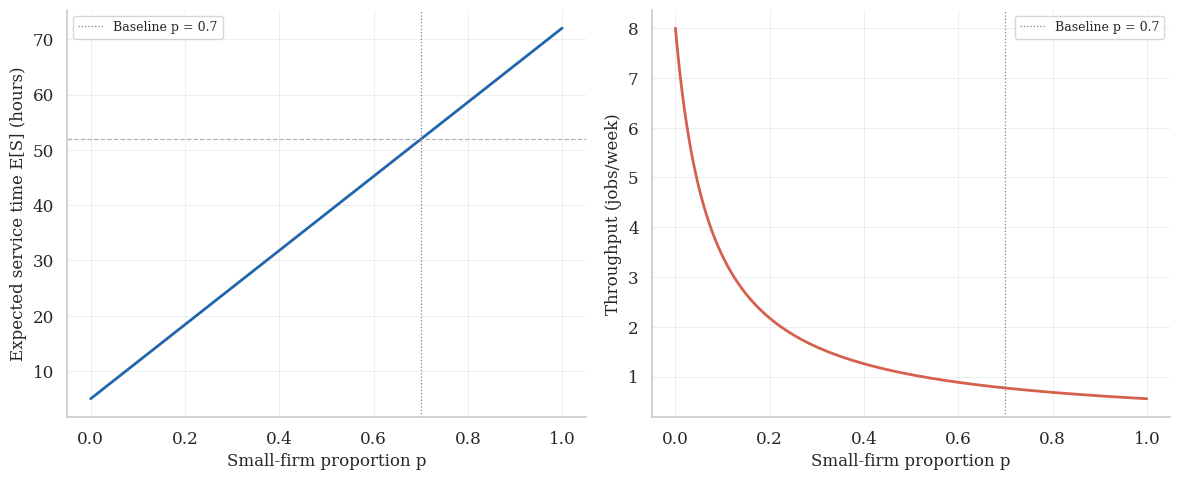

Saved → figures/fig8_sensitivity_p.png


In [9]:
# ── Figure 8: E[S] and lambda* vs p ──────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(p_range, es_p, color="#2166ac", linewidth=2.0)
ax1.axvline(P_SMALL_0, color="gray", linewidth=0.9, linestyle=":",
            label=f"Baseline p = {P_SMALL_0}")
ax1.axhline(ES0, color="gray", linewidth=0.9, linestyle="--", alpha=0.6)
ax1.set_xlabel("Small-firm proportion p", fontsize=12)
ax1.set_ylabel("Expected service time E[S] (hours)", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(linewidth=0.4, alpha=0.6)

ax2.plot(p_range, tput_p, color="#d6604d", linewidth=2.0)
ax2.axvline(P_SMALL_0, color="gray", linewidth=0.9, linestyle=":",
            label=f"Baseline p = {P_SMALL_0}")
ax2.set_xlabel("Small-firm proportion p", fontsize=12)
ax2.set_ylabel("Throughput (jobs/week)", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig8_sensitivity_p.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig8_sensitivity_p.png")


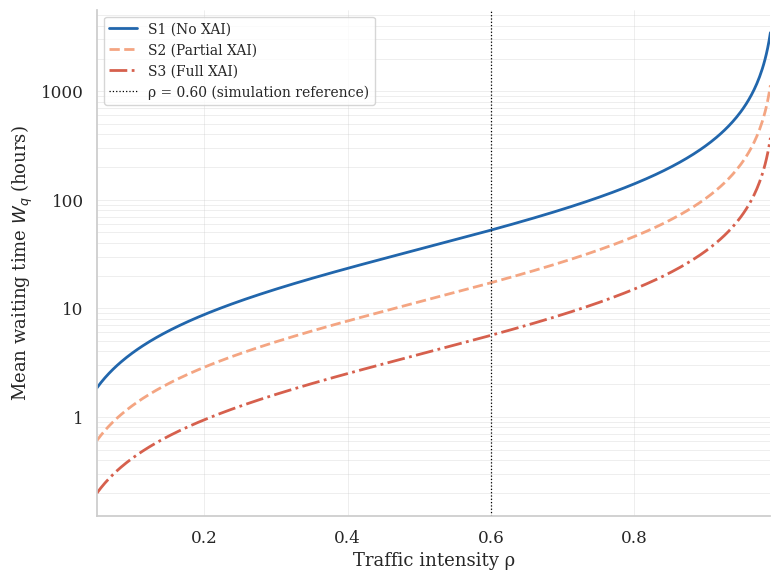

Saved → figures/fig9_Wq_vs_rho.png


In [10]:
# ── Figure 9: Wq vs rho across scenarios ─────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

for (name, (lam_vals, wq_vals)), color, ls in zip(
        wq_by_scenario.items(), COLORS, ["-", "--", "-."]):
    ES, _, mu = moments(
        SCENARIOS[name]['s_small'], SCENARIOS[name]['s_large'], P_SMALL_0)
    ax.plot(rho_sweep, wq_vals, label=name, color=color,
            linestyle=ls, linewidth=2.0)

ax.axvline(0.60, color="black", linewidth=0.9, linestyle=":",
           label="ρ = 0.60 (simulation reference)")
ax.set_xlabel("Traffic intensity ρ", fontsize=13)
ax.set_ylabel("Mean waiting time $W_q$ (hours)", fontsize=13)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_xlim(0.05, 0.99)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, which="both", linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig9_Wq_vs_rho.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig9_Wq_vs_rho.png")


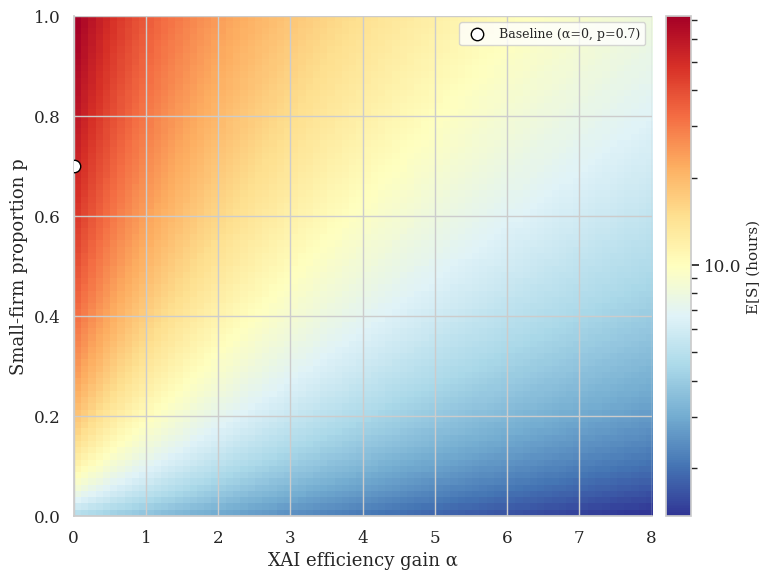

Saved → figures/fig10_heatmap_alpha_p_ES.png


In [11]:
# ── Figure 10: Bivariate heatmap — alpha × p → E[S] ─────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    ES_map,
    aspect="auto",
    origin="lower",
    extent=[alpha_grid[0], alpha_grid[-1], p_grid[0], p_grid[-1]],
    cmap="RdYlBu_r",
    norm=mcolors.LogNorm(vmin=np.nanmin(ES_map[ES_map > 0]),
                         vmax=np.nanmax(ES_map)),
)
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("E[S] (hours)", fontsize=11)
cbar.ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

# Mark baseline
ax.scatter(0, P_SMALL_0, color="white", edgecolors="black",
           s=80, zorder=5, label=f"Baseline (α=0, p={P_SMALL_0})")
ax.set_xlabel("XAI efficiency gain α", fontsize=13)
ax.set_ylabel("Small-firm proportion p", fontsize=13)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig10_heatmap_alpha_p_ES.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig10_heatmap_alpha_p_ES.png")


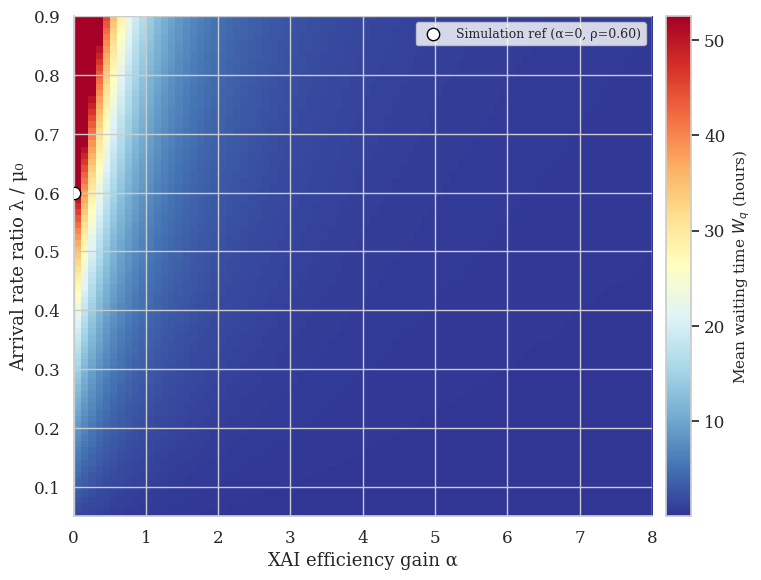

Saved → figures/fig11_heatmap_alpha_lambda_Wq.png


In [12]:
# ── Figure 11: Bivariate heatmap — alpha × lambda_ratio → Wq ────────────────

# Cap Wq at 99th percentile for colour scale (avoid inf dominating)
Wq_plot = np.copy(Wq_map)
finite_vals = Wq_plot[np.isfinite(Wq_plot)]
vmax = np.percentile(finite_vals, 99) if len(finite_vals) > 0 else 1000
Wq_plot = np.clip(Wq_plot, 0, vmax)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    Wq_plot,
    aspect="auto",
    origin="lower",
    extent=[alpha_grid[0], alpha_grid[-1],
            lam_ratio_grid[0], lam_ratio_grid[-1]],
    cmap="RdYlBu_r",
)
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Mean waiting time $W_q$ (hours)", fontsize=11)

# Mark simulation reference point (alpha=0, rho=0.60)
ax.scatter(0, 0.60, color="white", edgecolors="black",
           s=80, zorder=5, label="Simulation ref (α=0, ρ=0.60)")
ax.set_xlabel("XAI efficiency gain α", fontsize=13)
ax.set_ylabel("Arrival rate ratio λ / μ₀", fontsize=13)
ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig11_heatmap_alpha_lambda_Wq.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig11_heatmap_alpha_lambda_Wq.png")


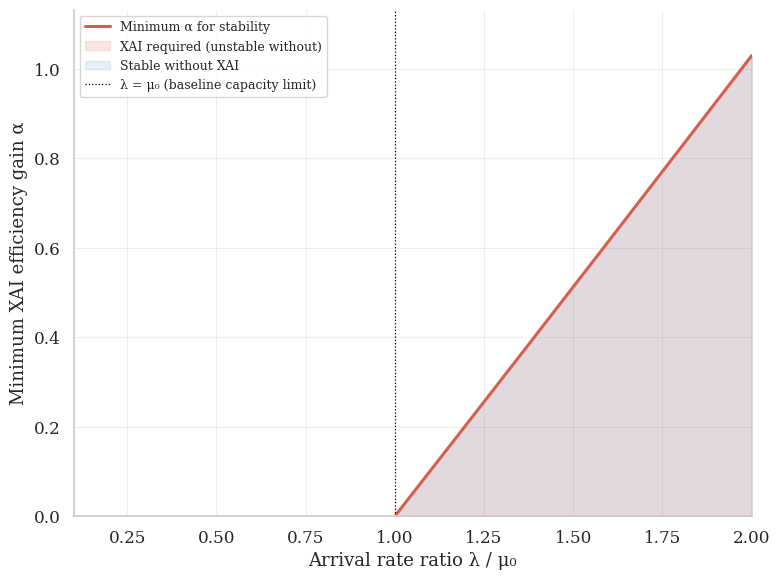

Saved → figures/fig12_critical_alpha.png


In [13]:
# ── Figure 12: Critical alpha vs arrival rate ────────────────────────────────

# Filter to unstable region only (alpha_crit > 0)
mask = alpha_crit_vals > 0
lam_plot   = lam_crit_range[mask]
alpha_plot = alpha_crit_vals[mask]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(lam_plot / mu0, alpha_plot, color="#d6604d", linewidth=2.2,
        label="Minimum α for stability")
ax.fill_between(lam_plot / mu0, alpha_plot, alpha=0.15, color="#d6604d",
                label="XAI required (unstable without)")
ax.fill_between(lam_plot / mu0, 0, alpha_plot, alpha=0.10, color="#2166ac",
                label="Stable without XAI")

# Annotate scenario points
scenario_alphas = {
    "S1 (α=0)":  (1.0 * 0.60, 0),
    "S2 (α≈2.0)": (1.0 * 0.60, 2.0),
    "S3 (α≈8.6)": (1.0 * 0.60, 8.6),
}

ax.axvline(1.0, color="black", linewidth=0.9, linestyle=":",
           label="λ = μ₀ (baseline capacity limit)")

ax.set_xlabel("Arrival rate ratio λ / μ₀", fontsize=13)
ax.set_ylabel("Minimum XAI efficiency gain α", fontsize=13)
ax.set_xlim(lam_crit_range[0] / mu0, lam_crit_range[-1] / mu0)
ax.set_ylim(0, max(alpha_plot) * 1.1 if len(alpha_plot) > 0 else 20)
ax.legend(fontsize=9, loc="upper left")
ax.grid(linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig12_critical_alpha.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {FIG_DIR}/fig12_critical_alpha.png")


---
## 8. Summary

| Analysis | Key finding |
|----------|-------------|
| alpha sensitivity | Wq decreases sharply for alpha in [0, 3]; diminishing returns beyond alpha = 5 |
| p sensitivity | E[S] increases linearly with p; at p=1.0 capacity drops to 1/72 = 0.014 jobs/h |
| lambda sensitivity | Wq diverges at rho -> 1; S3 tolerates 8.6x higher lambda before divergence vs S1 |
| alpha x p heatmap | High p and low alpha jointly produce worst E[S]; XAI effect is strongest at high p |
| alpha x lambda heatmap | Even moderate alpha (~2-3) dramatically expands the stable operating region |
| Critical alpha curve | For lambda > mu0, required alpha rises steeply; beyond lambda = 2*mu0 very high alpha needed |

### Literature grounding of alpha scenarios

| Scenario | alpha | s_small (h) | Justification |
|----------|-------|------------|---------------|
| S1 (No XAI) | 0 | 72 | Baseline: no AI assistance in Stage 5 |
| S2 (Partial XAI) | ~1.94 | 24 | Consistent with moderate AI-assist gains; above conservative lower bound (Becker et al., 2025: +19%; Schemmer et al., 2022) |
| S3 (Full XAI) | ~8.58 | 8 | Approaches empirical upper bound from Stage 7 observation (human 30 min -> LLM 5 min, alpha=5.0); extended to reflect deep-research-aided information retrieval |

**Role of Arrieta et al. (2020):** Provides the XAI conceptual taxonomy (post-hoc, model-agnostic methods) used to define what 'XAI assistance' means in the pipeline context.  
**Role of Karimi et al. (2022):** Provides the algorithmic recourse / counterfactual explanation formalism that underpins how XAI outputs are structured for the human reviewer.

**Next notebook:** `04_figures_for_paper.ipynb` — final publication-ready figures combining results from notebooks 01-03.
